# Simple real NISAR GUNW workflow

This notebook is intentionally small. Set `SNOWIN_GUNW` to a local NISAR GUNW product and optionally set `SNOWIN_NISAR_DEM` to a cached NISAR-modified Copernicus DEM. If no local DEM is provided, SnowIn will use its normal download/cache path.

In [3]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from snowin import compute_dswe
from snowin.io import open_gunw
from snowin.io.gunw import read_attrs_hdf5, read_scalar_hdf5

gunw_text = os.environ.get("SNOWIN_GUNW")
if not gunw_text:
    gunw_text = input("Enter the path to a local NISAR GUNW product: ").strip()
if not gunw_text:
    raise RuntimeError("A local NISAR GUNW product path is required.")
GUNW_PATH = Path(gunw_text).expanduser().resolve()
DEM_PATH = os.environ.get("SNOWIN_NISAR_DEM")
DEM_CACHE = Path(os.environ.get("SNOWIN_DEM_CACHE", "~/.cache/snowin/dem")).expanduser()
print("GUNW:", GUNW_PATH)
print("Local NISAR DEM:", DEM_PATH or "automatic download/cache")

Enter the path to a local NISAR GUNW product:  /Users/jtarrico/ch13_nisar_prelim/data/nisar/gunw/provisional/erb/asc/T019_F021/NISAR_L2_PR_GUNW_004_019_A_021_005_4000_SH_20251030T121115_20251030T121143_20251111T121116_20251111T121144_P05023_N_F_J_001


GUNW: /Users/jtarrico/ch13_nisar_prelim/data/nisar/gunw/provisional/erb/asc/T019_F021/NISAR_L2_PR_GUNW_004_019_A_021_005_4000_SH_20251030T121115_20251030T121143_20251111T121116_20251111T121144_P05023_N_F_J_001
Local NISAR DEM: automatic download/cache


## Inspect product metadata

In [4]:
phase_path = "science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH/unwrappedPhase"
height_path = "science/LSAR/GUNW/metadata/radarGrid/heightAboveEllipsoid"
reference_path = "science/LSAR/identification/referenceZeroDopplerStartTime"
secondary_path = "science/LSAR/identification/secondaryZeroDopplerStartTime"

print("phase attributes:", read_attrs_hdf5(GUNW_PATH, phase_path))
print("height attributes:", read_attrs_hdf5(GUNW_PATH, height_path))
print("reference time:", read_scalar_hdf5(GUNW_PATH, reference_path))
print("secondary time:", read_scalar_hdf5(GUNW_PATH, secondary_path))

phase attributes: {'DIMENSION_LIST': [array([<HDF5 object reference>], dtype=object), array([<HDF5 object reference>], dtype=object)], '_FillValue': nan, 'description': 'Unwrapped interferogram between HH layers', 'grid_mapping': 'projection', 'max_value': 13.980478286743164, 'mean_value': -8.561155319213867, 'min_value': -27.86049461364746, 'sample_stddev': 8.531492233276367, 'units': 'radians'}
height attributes: {'CLASS': 'DIMENSION_SCALE', 'NAME': '', 'REFERENCE_LIST': [(<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0), (<HDF5 object reference>, 0)], 'description': 'Height values above WGS8

## Open the GUNW with SnowIn

Phase/product arrays remain lazy when Dask is installed. DEM reprojection and local-incidence geometry are materialized by the current implementation.

In [5]:
open_kwargs = {"dem_cache_dir": DEM_CACHE, "chunks": "auto"}
if DEM_PATH:
    open_kwargs["nisar_cop30_dem"] = Path(DEM_PATH).expanduser()

pair = open_gunw(GUNW_PATH, **open_kwargs)
print(pair)
print("phase transform:", pair.attrs.get("phase_transform"))
print("DEM source:", pair.attrs.get("dem_source"))
print("wavelength [m]:", pair.attrs.get("wavelength_m"))

<xarray.Dataset> Size: 307MB
Dimensions:              (y: 4347, x: 4410)
Coordinates:
  * y                    (y) float64 35kB 4.445e+06 4.445e+06 ... 4.098e+06
  * x                    (x) float64 35kB 2.42e+05 2.42e+05 ... 5.947e+05
    spatial_ref          uint32 4B 32613
Data variables:
    phase                (y, x) float32 77MB dask.array<chunksize=(4347, 4410), meta=np.ndarray>
    incidence_angle      (y, x) float32 77MB 1.015 1.077 1.15 ... 0.601 0.6105
    coherence            (y, x) float32 77MB dask.array<chunksize=(4347, 4410), meta=np.ndarray>
    connected_component  (y, x) float32 77MB dask.array<chunksize=(4347, 4410), meta=np.ndarray>
Attributes: (12/28)
    snowin_schema_version:               0.1-draft
    product_kind:                        pairwise_interferogram
    reference_time:                      2025-10-30T12:11:15Z
    secondary_time:                      2025-11-11T12:11:16Z
    temporal_edge:                       reference_to_secondary
    phase_diff

## Preview phase, local incidence, and pairwise dSWE

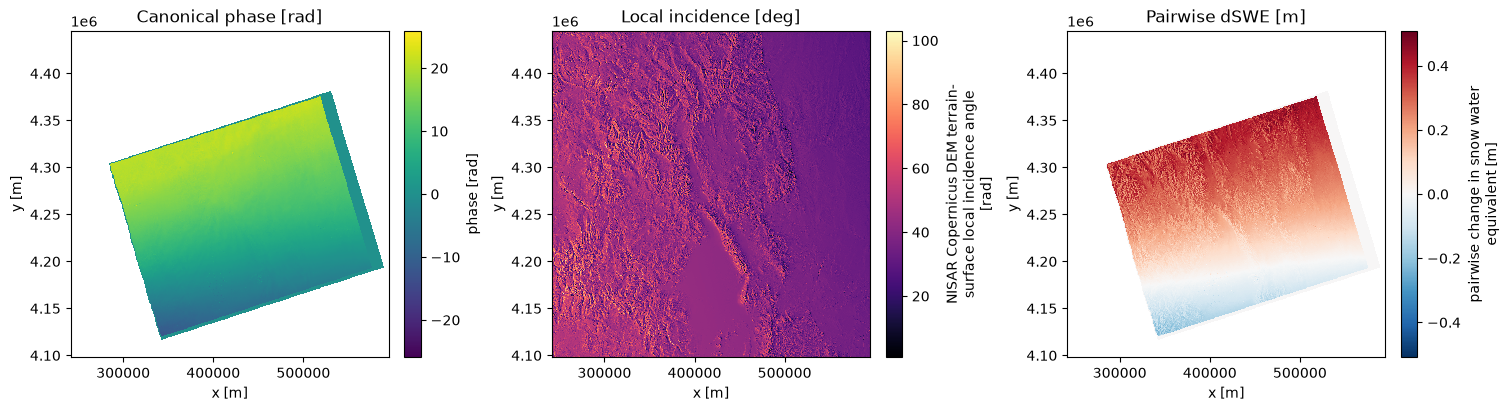

In [6]:
step = max(1, min(pair.sizes.values()) // 600)
phase_preview = pair["phase"].isel(y=slice(None, None, step), x=slice(None, None, step))
incidence_preview = np.rad2deg(pair["incidence_angle"]).isel(y=slice(None, None, step), x=slice(None, None, step))
valid_geometry = (pair["incidence_angle"] >= 0) & (pair["incidence_angle"] < np.pi / 2)
safe_incidence = pair["incidence_angle"].where(valid_geometry)
dswe = compute_dswe(
    pair["phase"],
    safe_incidence,
    wavelength_m=float(pair.attrs["wavelength_m"]),
)
dswe_preview = dswe.isel(y=slice(None, None, step), x=slice(None, None, step))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
phase_preview.plot(ax=axes[0], cmap="viridis")
axes[0].set_title("Canonical phase [rad]")
incidence_preview.plot(ax=axes[1], cmap="magma")
axes[1].set_title("Local incidence [deg]")
dswe_preview.plot(ax=axes[2], cmap="RdBu_r")
axes[2].set_title("Pairwise dSWE [m]")
plt.show()

In [7]:
print("phase definition:", pair.attrs.get("phase_difference_definition"))
print("incidence reference:", pair["incidence_angle"].attrs.get("incidence_angle_reference"))
print("finite phase fraction:", float(np.isfinite(phase_preview).mean()))
print("finite dSWE fraction:", float(np.isfinite(dswe_preview).mean()))
pair.close()

phase definition: secondary_minus_reference
incidence reference: local
finite phase fraction: 0.4153490274263221
finite dSWE fraction: 0.41534135930271193
